In [1]:
!pip install datasets
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 14.2 MB/s eta 0:00:00


In [2]:
# importing the libraries
import logging
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from PIL import Image
import torch
import time
from groq import Groq
from PIL import Image
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [ ]:
# settings for the api provided by Groq to use LLMS
# Groq API settings. Set GROQ_API_KEY as an environment variable,
# or add it in Colab under the key icon (Secrets) with the name GROQ_API_KEY.
import os
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
if not GROQ_API_KEY:
    try:
        from google.colab import userdata
        GROQ_API_KEY = userdata.get("GROQ_API_KEY")
    except Exception:
        from getpass import getpass
        GROQ_API_KEY = getpass("Enter your Groq API key: ")
LLAMA_DEPLOYMENT_NAME = "llama-3.3-70b-versatile"
LLAMA_DEPLOYMENT_NAME = "llama-3.3-70b-versatile"

In [4]:
# Configure logger
logger = logging.getLogger(__name__)


def load_blip2_model(model_name="Salesforce/blip2-opt-2.7b"):
    """
    Load BLIP‑2 model and processor.
    """
    processor = Blip2Processor.from_pretrained(model_name)
    model = Blip2ForConditionalGeneration.from_pretrained(model_name)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    logger.info(f"BLIP‑2 model loaded on {device}.")
    return processor, model, device

def generate_caption(image, processor, model, device):
    """
    Generate a caption for a single image.

    Args:
        image: A PIL.Image, file path, or image array.
        processor: The BLIP‑2 processor.
        model: The BLIP‑2 model.
        device: Inference device.

    Returns:
        Caption string.
    """
    if isinstance(image, str):
        image = Image.open(image)
    elif not isinstance(image, Image.Image):
        try:
            image = Image.fromarray(image)
        except Exception as e:
            logger.error(f"Image conversion error: {e}")
            raise e

    inputs = processor(image, return_tensors="pt").to(device)
    generated_ids = model.generate(**inputs)
    caption = processor.decode(generated_ids[0], skip_special_tokens=True)
    return caption

def process_scene_frames(scenes, processor, model, device):
    """
    Process the list of scenes, each containing multiple frames, and generate captions.

    Args:
        scenes: List[List[Image]] where each inner list is a scene.
        processor, model, device: BLIP‑2 components.

    Returns:
        A list of lists of captions (one inner list per scene).
    """
    scene_captions = []
    for scene_index, scene_frames in enumerate(scenes):
        captions = []
        logger.info(f"Processing scene {scene_index+1} with {len(scene_frames)} frame(s).")
        for frame_index, frame in enumerate(scene_frames):
            try:
                caption = generate_caption(frame, processor, model, device)
                captions.append(caption)
                logger.debug(f"Scene {scene_index+1}, Frame {frame_index+1}: {caption}")
            except Exception as e:
                logger.error(f"Error on scene {scene_index+1}, frame {frame_index+1}: {e}")
                captions.append("Error generating caption")
        scene_captions.append(captions)
    return scene_captions

def generate_story_with_llama(captions, previous_context=None, prompt_template=None):
    """
    Use Groq API to generate a story with LLaMA, strictly based on the provided captions.

    Args:
        captions: List of captions to feed into LLaMA.
        prompt_template: Optional custom prompt template. Should include a placeholder {captions} for captions.

    Returns:
        A generated story based solely on the captions.
    """
    # Prepare the input prompt by joining the captions with bullet points excluding faulty ones
    unique_captions = []
    for c in captions:
        # Only add it if it's not an error AND not exactly the same as the last one
        if c != "Error generating caption" and (not unique_captions or c != unique_captions[-1]):
            unique_captions.append(c)

    joined_captions = "\n".join([f"- {c}" for c in unique_captions])
    # 2. Context-Aware Pipeline Logic
    if previous_context:
        context_block = f"PREVIOUS SCENE CONTEXT (What just happened):\n{previous_context}\n\n"
        task_desc = "Your task is to seamlessly continue the story from the previous scene, based strictly on the new captions for the current scene."
    else:
        context_block = ""
        task_desc = "Your task is to weave these discrete captions into a single, cohesive, and concise short story."

    # Build the user prompt using either a custom template or the default structure
    if prompt_template:
        user_content = prompt_template.format(captions=joined_captions)
    else:
        user_content = f"\n{context_block}CURRENT SCENE CAPTIONS:\n{joined_captions}\n\nGenerate the story for the current scene:"

    # Refined system message to ensure adherence to provided details
    system_message = (
        "You are an expert narrative storyteller. "
        f"{task_desc} "
        "CONSTRAINTS: "
        "1. Maintain temporal coherence. If there is previous context, ensure the new actions logically follow it. "
        "2. Do not introduce new characters, objects, or excessive details not explicitly mentioned in the captions. "
        "3. Fill the logical gaps between actions naturally, but keep the narrative focused strictly on the physical events occurring. "
        "4. Keep the tone observational and direct. DO NOT mention 'the camera', 'blurry images', 'the viewer', or the fact that this is a video. Describe the events as if they are happening in reality. "
        "5. OUTPUT ONLY THE STORY TEXT. DO NOT INCLUDE ANY INTRODUCTIONS, CONCLUSIONS, EXPLANATIONS, OR NOTES."
    )
    # Create the chat client using the Groq API
    client = Groq(api_key=GROQ_API_KEY)

    # Assemble the messages for the chat completion
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_content}
    ]
    try:
        # Request story generation from the client
        response = client.chat.completions.create(
            model=LLAMA_DEPLOYMENT_NAME,
            messages=messages,
            temperature=0.1,  # Lower temperature for more deterministic responses
            max_tokens=500
        )

        if response and response.choices:
            story = response.choices[0].message.content
            logger.info("Story generated successfully.")
            return story.strip()
        else:
            logger.error("Empty response received from Groq API")
            return None
    except Exception as e:
        logger.error(f"Error in generating story: {e}")
        time.sleep(5)
        return None


In [5]:
#Loading the dataset
logger.info("Loading dataset...")
dataset = load_dataset("ingoziegler/StoryFrames", split="train", streaming=True)
#Each video is a story saved as a dictionary
dataset_samples = list(dataset.take(10))
logger.info(f"Loaded {len(dataset_samples)} samples.")

README.md:   0%|          | 0.00/6.02k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/49 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/55 [00:00<?, ?it/s]

In [6]:
#Loading the pretrained models
processor, blip2_model, device = load_blip2_model()

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/122k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [7]:
# Generating the captions for scenes
all_scene_captions = []  # list of (story_id, scene captions)
for sample_index, sample in enumerate(dataset_samples):
  story_id = sample.get("story_id", "N/A")
  logger.info(f"Processing sample {sample_index+1} (Story ID: {story_id}).")
  scenes = sample.get("scenes", [])
  if not scenes:
    logger.warning(f"No scenes in sample {sample_index+1}. Skipping.")
    continue
  scene_captions = process_scene_frames(scenes, processor, blip2_model, device)
  all_scene_captions.append((story_id, scene_captions))
  if torch.cuda.is_available():
        torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1616: UserWarning: Using the model-agnostic default `max_length` (=53) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


In [8]:
def evaluate_story_quantitatively(ground_truth_text, generated_story):
    """
    Use Groq API (LLaMA) to evaluate the story against the Human Ground Truth (SimRate).
    """

    judge_prompt = f"""You are an objective AI evaluator. Compare the AI-Generated Story to the Human-Annotated Ground Truth.
    Output ONLY a JSON object with three scores from 1 to 10. Do not output markdown.

    Human Ground Truth:
    {ground_truth_text}

    AI-Generated Story:
    {generated_story}

    Metrics:
    - "semantic_similarity": How well does the story capture the exact events described in the Ground Truth? (1-10)
    - "coherence": Do the events flow in a logical, chronological order? (1-10)
    - "style": Is the writing natural and cinematic? (1-10)

    Format example: {{"semantic_similarity": 8, "coherence": 9, "style": 7}}"""

    client = Groq(api_key=GROQ_API_KEY)

    try:
        response = client.chat.completions.create(
            model=LLAMA_DEPLOYMENT_NAME,
            messages=[{"role": "user", "content": judge_prompt}],
            temperature=0.0,
            max_tokens=150,
            response_format={"type": "json_object"}
        )

        if response and response.choices:
            return json.loads(response.choices[0].message.content.strip())
        return None
    except Exception as e:
        logger.error(f"Error in evaluating story: {e}")
        return None

In [9]:
all_sim_scores = []
all_coh_scores = []
all_style_scores = []
for sample_index, (story_id, scene_captions) in enumerate(all_scene_captions):
  # Fetch ground truth and video details from the dataset
  original_sample = dataset_samples[sample_index]
  ground_truth_descriptions = original_sample.get("sentence_parts", [])
  video_name = original_sample.get("video_name", "Unknown Video")
  logger.info(f"\nGenerating story for sample {sample_index+1} (Story ID: {story_id})")
  # Reset the memory for each new video/story
  previous_story_context = None
  for scene_index, captions in enumerate(scene_captions):
    # Pass the previous scene's context!
      story = generate_story_with_llama(captions, previous_context=previous_story_context)
      if story:
        # Save this story to be the context for the NEXT scene
        previous_story_context = story
        print(f"\n{'='*70}")
        print(f"\nScene {scene_index+1} (Video: {video_name}) Story (Story ID: {story_id}):")
        print(f"\n{'='*70}")
      # Safely get ground truth for this scene
        gt_text = "No ground truth available."
        if scene_index < len(ground_truth_descriptions):
            gt_text = ground_truth_descriptions[scene_index]
            print(f"GROUND TRUTH:\n  {gt_text}\n")

        print(f"GENERATED STORY:\n  {story}\n")
        # RUN THE EVALUATION AGAINST THE GROUND TRUTH
        if gt_text != "No ground truth available.":
            scores = evaluate_story_quantitatively(gt_text, story)
            if scores:
                sim = scores.get('semantic_similarity', 0)
                coh = scores.get('coherence', 0)
                sty = scores.get('style', 0)

                all_sim_scores.append(sim)
                all_coh_scores.append(coh)
                all_style_scores.append(sty)

                print(f"--- LLM-AS-A-JUDGE SCORES ---")
                print(f"Semantic Similarity (SimRate): {sim}/10")
                print(f"Coherence:                     {coh}/10")
                print(f"Style:                         {sty}/10")
        print("-" * 70)



Scene 1 (Video: 10287726@N02_3668334480_3e44bb6f8d.mov) Story (Story ID: 10287726@N02_3668334480_3e44bb6f8d.mov---10287726@N02_3668334480_3e44bb6f8d.mov):

GROUND TRUTH:
  A tank on which two people are sitting is moving to the left side and camera is capturing the tank and moves to the left side while a group of people are watching the tank a person wearing an orange safety jacket is standing on the soil surface.

GENERATED STORY:
  A tank was parked next to a jeep, and a man stood watching it. Then, the tank began to move, driving down the road as people gathered to watch. It continued on, turning onto a dirt road that ran alongside a field. The tank drove down this dirt road, passing by a man who stood in the field, observing its movement.

As it proceeded, the tank entered the field itself, driving on the grass. A man climbed onto the back of the tank, and it continued to move forward, now driving up a ramp in the field. The tank then drove down the ramp and back onto the dirt ro


[INFO] Generating Performance Graph...


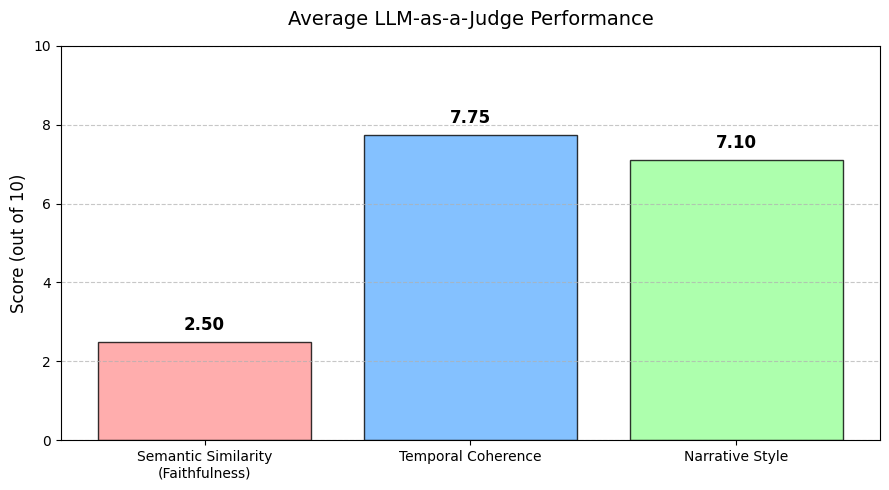

In [10]:
# ==========================================
# DRAW THE GRAPH
# ==========================================
if all_sim_scores:
    print("\n[INFO] Generating Performance Graph...")

    avg_sim = np.mean(all_sim_scores)
    avg_coh = np.mean(all_coh_scores)
    avg_style = np.mean(all_style_scores)

    labels = ['Semantic Similarity\n(Faithfulness)', 'Temporal Coherence', 'Narrative Style']
    averages = [avg_sim, avg_coh, avg_style]
    colors = ['#FF9999', '#66B2FF', '#99FF99']

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, averages, color=colors, edgecolor='black', alpha=0.8)

    plt.ylim(0, 10)
    plt.title('Average LLM-as-a-Judge Performance', fontsize=14, pad=15)
    plt.ylabel('Score (out of 10)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

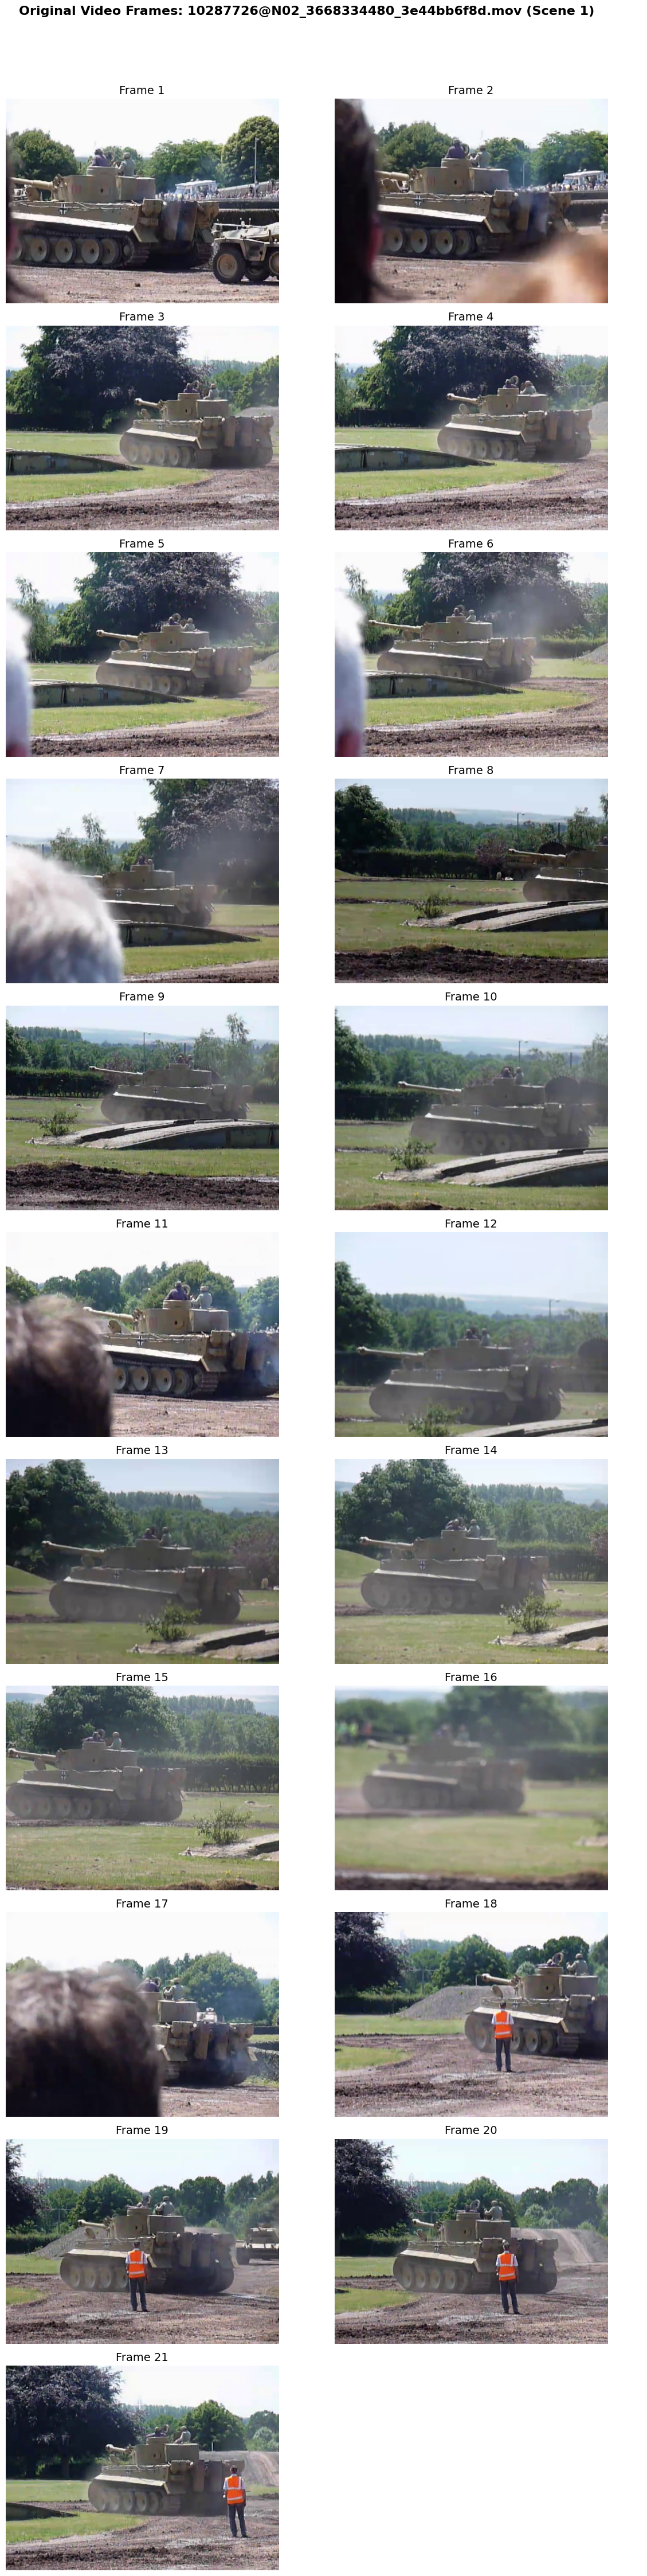

In [11]:
import matplotlib.pyplot as plt
import math

# Grab the first video in your dataset (change the 0 to see other videos)
sample = dataset_samples[0]
video_name = sample.get("video_name", "Unknown Video")

# Grab the frames from Scene 1
scene_1_frames = sample['scenes'][0]
num_frames = len(scene_1_frames)

# Setup a grid with 2 columns
cols = 2
rows = math.ceil(num_frames / cols)

# Make the figure large enough so the images look great
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))

# Flatten the axes array to make it easy to loop through
axes = axes.flatten() if num_frames > 1 else [axes]

for i in range(len(axes)):
    if i < num_frames:
        axes[i].imshow(scene_1_frames[i])
        axes[i].set_title(f"Frame {i+1}", fontsize=14)
    # Hide the axes/borders for a clean look, even on empty grid spots
    axes[i].axis('off')

plt.suptitle(f"Original Video Frames: {video_name} (Scene 1)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()